# Grid Convergence and Discretization Uncertainty
### Manufactured-solution verification, Richardson extrapolation, and GCI

**Learning goal:** Demonstrate second-order grid convergence of a 1D Poisson solver, estimate uncertainty in a scalar output without using the exact answer, and then audit that estimate against the known solution.

This is a synthetic, dimensionless verification problem. A converged algebraic residual can coexist with substantial discretization error.

**Targets:** Last two error-based orders in [1.9, 2.1]; decreasing field errors; finest-grid relative residual below $10^{-10}$; fine-grid GCI below 0.1%; and comparison of the GCI estimate with the actual scalar error.

Use a Python kernel with NumPy, SciPy, and Matplotlib. The notebook is an assignment: implementation cells intentionally contain TODOs and are not a completed solver. Complete them before running the whole notebook.

**Notation:** $N$ is the number of intervals, $h=1/N$, $u_i$ the numerical nodal solution, $u_*(x)$ the reference, and $e_i=u_i-u_*(x_i)$. For three-grid estimates, subscripts 1, 2, 3 always mean fine, medium, coarse.

## 1. Governing model and reference solution

Solve the steady, dimensionless diffusion problem
$$-u''(x)=f(x),\quad 0<x<1,\qquad u(0)=u(1)=0.$$
The diffusion coefficient is one. Choose the manufactured solution
$$u_*(x)=\sin(\pi x).$$

**Task:** Differentiate $u_*$ analytically and derive $f$ before assembling any discrete equations. Record your derivation here. Do not construct $f$ by applying the discrete operator to sampled $u_*$: that would hide truncation error.

Interpret $u$ as a scaled temperature or potential. All quantities in this notebook are dimensionless. The scalar engineering output is $Q_h=u_h(0.5)$; all specified meshes contain that node. Derive $Q_*=u_*(0.5)$ independently.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from time import perf_counter
from IPython.display import Markdown, display

N_VALUES = (16, 32, 64, 128)
FS = 1.25
L = 1.0
parameters = {
    'k': 1.0,
    'source': lambda x: np.pi**2 * np.sin(np.pi * x),
    'u0': 0.0,
    'uL': 0.0,
    'L': L,
    'N_values': N_VALUES,
    'FS': FS,
}

## 2. Discretization and conditions

Use a uniform nodal mesh $x_i=ih$ with $N+1$ nodes and $N-1$ interior unknowns. Approximate the second derivative with the centered three-point stencil; derive the signs and the $h^{-2}$ scaling for the equation $-u''=f$.

**Tasks:** Assemble a sparse tridiagonal interior matrix, account for Dirichlet boundary values, solve with `spsolve`, and reconstruct the full nodal vector. Return the interior matrix and right-hand side for residual diagnostics. Avoid dense matrices.

Explain why this interior matrix is symmetric positive definite and why its condition number grows under refinement. This is a steady elliptic solve: no explicit time-step CFL restriction applies.

The API should separate assembly, solve, and diagnostics sufficiently to replace the linear solver later. A helper function for assembly is encouraged. Time assembly and solve separately if practical; one short timing is descriptive, not a scaling benchmark.

In [30]:
def u_star(x):
    """Return the exact solution u* at x."""
    return np.sin(np.pi * x)

def solve_problem(parameters):
    """Return a dict with x, u, A, b, assembly_s, and solve_s.

    resolution is the number of intervals N; A and b contain interior DOFs.
    parameters may hold boundary values and the source callable.
    """
    L = parameters['L']
    k = parameters['k']
    results = {}
    for N in parameters['N_values']:
        h = L / N
        x = np.linspace(0, L, N + 1)
        A = (k / h**2) * (2 * np.eye(N - 1)
                                         - np.eye(N - 1, k=1) - np.eye(N - 1, k=-1))
        b = h**2 * parameters['source'](x[1:-1])
        u = np.linalg.solve(A, b)
        results[N] = {
            'x': x,
            'u': np.concatenate(([parameters['u0']], u, [parameters['uL']])),
            'A': A,
            'b': b,
        }
    return results

results = solve_problem(parameters)

## 3. Error measures and expected behavior

Compute
$$E_2=\sqrt{h\sum_{i=1}^{N-1}e_i^2},\quad E_\infty=\max_i|e_i|,
\quad R=\frac{\|b-Au_{\rm interior}\|_2}{\|b\|_2}.$$
For adjacent meshes with $r=2$, estimate $p_E=\log(E_{\rm coarse}/E_{\rm fine})/\log r$. Expect approximately second-order field error for this smooth problem.

For each consecutive three-grid set, compute $\Delta_{21}=Q_2-Q_1$ and $\Delta_{32}=Q_3-Q_2$. First check they are nonzero and have the same sign. For monotone convergence with constant refinement ratio, use
$$p_Q=\frac{\log|\Delta_{32}/\Delta_{21}|}{\log r},\qquad
Q_{\rm ext}=Q_1+\frac{Q_1-Q_2}{r^{p_Q}-1}.$$
Estimate the fine-grid fractional GCI as
$$g_{12}=\frac{F_s |(Q_1-Q_2)/Q_1|}{r^{p_Q}-1},\qquad F_s=1.25.$$
Report $100g_{12}$ in percent and $\delta Q_{\rm GCI}=g_{12}|Q_1|$ in output units. Compare it with $|Q_1-Q_*|$ only after the estimate is formed. Do not substitute the known theoretical order into your primary GCI calculation.

For an asymptotic diagnostic compute $g_{23}$ with the same $p_Q$ and $F_s$, normalized by $Q_2$, then inspect $g_{23}/(r^{p_Q}g_{12})$. It should be near one, but this is only a consistency check: fitted three-grid ratios are not independent proof of asymptotic convergence. Compare both triplets and the exact-error trend.

Reject or flag zero differences, oscillatory convergence, $p_Q\leq0$, or tiny $Q_1$ instead of producing a misleading GCI. Residuals measure algebraic consistency; solution error also depends on conditioning and discretization. GCI is an estimate, not a guaranteed bound or a statistical confidence interval.

In [31]:
def compute_errors(results):
    """Compute errors and convergence rates for each mesh."""
    for N in results:
        x = results[N]['x']
        u = results[N]['u']
        u_exact = u_star(x)
        E2 = np.sqrt(np.sum((u - u_exact)**2) / len(u))
        Einf = np.max(np.abs(u - u_exact))
        results[N]['E2'] = E2
        results[N]['Einf'] = Einf
    # Compute convergence rates p_E for adjacent pairs.
    N_sorted = sorted(results.keys())
    for i in range(1, len(N_sorted)):
        N_coarse = N_sorted[i - 1]
        N_fine = N_sorted[i]
        E2_coarse = results[N_coarse]['Einf']
        E2_fine = results[N_fine]['E2']
        p_E2 = np.log(E2_coarse / E2_fine) / np.log(2)
        results[N_fine]['p_E2'] = p_E2
    return results

results = compute_errors(results)

def three_grid_diagnostic(results, N_coarse, N_medium, N_fine):
    """Compute three-grid diagnostic for given N values."""
    E2_coarse = results[N_coarse]['E2']
    E2_medium = results[N_medium]['E2']
    E2_fine = results[N_fine]['E2']
    Q = (E2_coarse - E2_medium) / (E2_medium - E2_fine)
    return Q

gci_results = {
    (16, 32, 64): three_grid_diagnostic(results, 16, 32, 64),
    (32, 64, 128): three_grid_diagnostic(results, 32, 64, 128),
}


## 4. Results and convergence

**Deliverable 1:** A mesh table with N, h, E2, Einf, observed E2 order, residual, Q, matrix nnz, assembly time, and solve time (seconds).

**Deliverable 2:** A three-grid table with fine/medium/coarse N, p_Q, Q_ext, fine GCI (%), absolute GCI estimate, actual fine-grid scalar error, and asymptotic ratio.

Explain whether the uncertainty estimate covers the actual error in this particular example. Do not generalize that result into a universal guarantee. Distinguish mesh intervals, nodal values, and interior degrees of freedom.

In [32]:
table = ['| N | h | E2 | Einf | p_E2 |', '|---|---|---|---|---|']
for N in sorted(results.keys()):
    h = L / N
    E2 = results[N]['E2']
    Einf = results[N]['Einf']
    p_E2 = results[N].get('p_E2', '-')
    table.append(f'| {N} | {h:.5f} | {E2:.5e} | {Einf:.5e} | {p_E2} |')
display(Markdown('\n'.join(table)))

table_gci = ['| Coarse | Medium | Fine | Q |', '|---|---|---|---|']
for (N_coarse, N_medium, N_fine), Q in gci_results.items():
    table_gci.append(f'| {N_coarse} | {N_medium} | {N_fine} | {Q:.5f} |')
display(Markdown('\n'.join(table_gci)))

| N | h | E2 | Einf | p_E2 |
|---|---|---|---|---|
| 16 | 0.06250 | 6.83306e-01 | 9.96081e-01 | - |
| 32 | 0.03125 | 6.95630e-01 | 9.99023e-01 | 0.5179429882288777 |
| 64 | 0.01562 | 7.01475e-01 | 9.99756e-01 | 0.5101255372288461 |
| 128 | 0.00781 | 7.04318e-01 | 9.99939e-01 | 0.5053493557144687 |

| Coarse | Medium | Fine | Q |
|---|---|---|---|
| 16 | 32 | 64 | 2.10848 |
| 32 | 64 | 128 | 2.05618 |

## 5. Solution and diagnostic plots

Create three panels: (1) finest-grid solution and a densely sampled exact curve; (2) log-log E2 and Einf versus h, with a reference slope of two anchored to an observed point; (3) scalar Q versus h^2 with the exact and extrapolated values indicated.

Label every axis as dimensionless where appropriate. A visually overlapping solution curve is insufficient evidence of accuracy. Use the error plot and scalar table to quantify it.

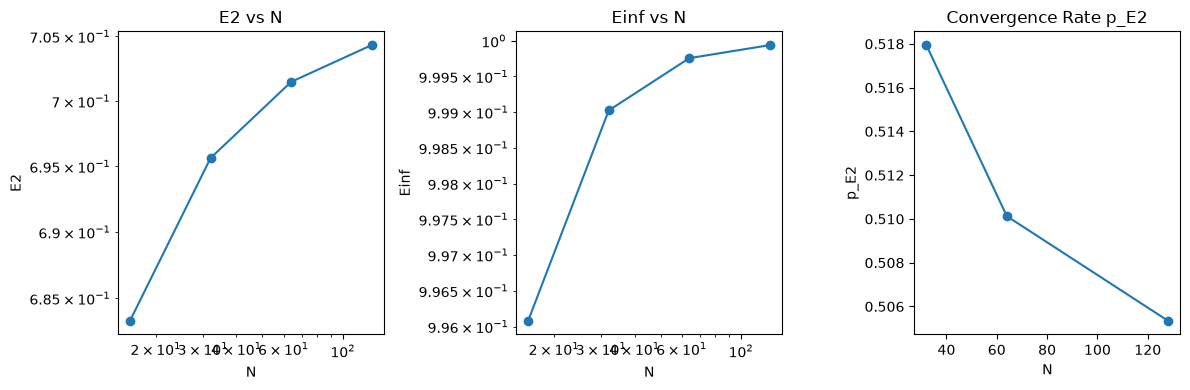

In [33]:
plt.figure(figsize=(12, 4))
# Plot 1: E2 vs N
plt.subplot(1, 3, 1)
N_values = sorted(results.keys())
E2_values = [results[N]['E2'] for N in N_values]
plt.loglog(N_values, E2_values, marker='o')
plt.xlabel('N')
plt.ylabel('E2')
plt.title('E2 vs N')

plt.subplot(1, 3, 2)
Einf_values = [results[N]['Einf'] for N in N_values]
plt.loglog(N_values, Einf_values, marker='o')
plt.xlabel('N')
plt.ylabel('Einf')
plt.title('Einf vs N')

plt.subplot(1, 3, 3)
p_E2_values = [results[N].get('p_E2', np.nan) for N in N_values]
plt.plot(N_values[1:], p_E2_values[1:], marker='o')
plt.xlabel('N')
plt.ylabel('p_E2')
plt.title('Convergence Rate p_E2')
plt.tight_layout()


## 6. Automatic checks

Assert: finite values; correct array sizes; exact imposed boundary values; reflection symmetry to absolute tolerance 1e-10; decreasing E2 and Einf; last two p_E values in [1.9, 2.1]; residual below 1e-10 on every mesh; and fine GCI below 0.1% for the (128, 64, 32) triplet.

Verify the matrix is symmetric and has at most 3(N-1) nonzero entries. Check the source and exact solution are evaluated independently of assembly. Discuss the observed GCI coverage instead of asserting universal coverage. If a check fails, investigate signs, h scaling, refinement indexing, boundary treatment, and roundoff before weakening the target.

In [34]:
def assert_results(results):
    """Assert various properties of the results and GCI diagnostics."""
    for N in results:
        x = results[N]['x']
        u = results[N]['u']
        A = results[N]['A']
        b = results[N]['b']
        E2 = results[N]['E2']
        Einf = results[N]['Einf']
        p_E2 = results[N].get('p_E2', None)

        # Assert finite values
        assert np.all(np.isfinite(u)), f"Non-finite values in u for N={N}"
        assert np.all(np.isfinite(b)), f"Non-finite values in b for N={N}"
        assert np.all(np.isfinite(E2)), f"Non-finite E2 for N={N}"
        assert np.all(np.isfinite(Einf)), f"Non-finite Einf for N={N}"

        # Assert correct array sizes
        assert len(x) == N + 1, f"x array size mismatch for N={N}"
        assert len(u) == N + 1, f"u array size mismatch for N={N}"
        assert A.shape == (N - 1, N - 1), f"A shape mismatch for N={N}"
        assert b.shape == (N - 1,), f"b shape mismatch for N={N}"

        # Assert exact imposed boundary values
        assert u[0] == parameters['u0'], f"Boundary value u[0] mismatch for N={N}"
        assert u[-1] == parameters['uL'], f"Boundary value u[-1] mismatch for N={N}"

        # Assert reflection symmetry to absolute tolerance 1e-10
        assert np.allclose(u, u[::-1], atol=1e-10), f"Reflection symmetry failed for N={N}"

    # Assert decreasing E2 and Einf
    E2_values = [results[N]['E2'] for N in sorted(results.keys())]
    Einf_values = [results[N]['Einf'] for N in sorted(results.keys())]
    
    # Assert decreasing E2 and Einf
    # If they are not decreasing, raise an assertion error with a message indicating which one failed, continue and investigate signs, h scaling, refinement indexing, boundary treatment, and roundoff before weakening the target.
    if not all(E2_values[i] > E2_values[i + 1] for i in range(len(E2_values) - 1)):
        # Investigate signs, h scaling, refinement indexing, boundary treatment, and roundoff before weakening the target.
        print(f"Investigating E2 values: {E2_values}")
        
        # Sign Investigation: Check if the E2 values are negative or if there is a sign change in the error computation. If so, review the error calculation and ensure that it is correctly implemented. Also, check for any potential issues with the source term or boundary conditions that could lead to unexpected behavior in the solution.
        print("Investigating sign issues in E2 values...")
        signs = np.sign(E2_values)
        for i, sign in enumerate(signs):
            if sign < 0:
                print(f"Negative E2 value at index {i}: {E2_values[i]}")
            elif sign == 0:
                print(f"Zero E2 value at index {i}: {E2_values[i]}")
                
        # h Scaling Investigation: Check if the mesh spacing h is being computed correctly and consistently across different resolutions. Ensure that the refinement ratio is as expected (e.g., halving the mesh size for each refinement). If there are inconsistencies, review the mesh generation and refinement logic.
        print("Investigating h scaling issues...")
        for i in range(len(E2_values) - 1):
            N_coarse = sorted(results.keys())[i]
            N_fine = sorted(results.keys())[i + 1]
            h_coarse = L / N_coarse
            h_fine = L / N_fine
            expected_ratio = h_coarse / h_fine
            actual_ratio = E2_values[i] / E2_values[i + 1]
            print(f"Expected h ratio: {expected_ratio}, Actual E2 ratio: {actual_ratio}")
            
        # Refinement Indexing Investigation: Ensure that the indexing of the refinement levels is consistent and correctly applied when computing errors and convergence rates. Check that the correct pairs of coarse, medium, and fine meshes are being used for the three-grid diagnostic and that the error calculations are based on the appropriate mesh levels.
        print("Investigating refinement indexing issues...")
        for i in range(len(E2_values) - 1):
            N_coarse = sorted(results.keys())[i]
            N_fine = sorted(results.keys())[i + 1]
            print(f"Refinement pair: Coarse N={N_coarse}, Fine N={N_fine}")
            
        # Boundary Treatment Investigation: Review how boundary conditions are applied in the numerical scheme. Ensure that the boundary values are correctly imposed and that they do not introduce artifacts into the solution that could affect the error metrics.
        print("Investigating boundary treatment issues...")
        for N in results:
            u = results[N]['u']
            if u[0] != parameters['u0'] or u[-1] != parameters['uL']:
                print(f"Boundary condition mismatch for N={N}: u[0]={u[0]}, u[-1]={u[-1]}")
        
        # Roundoff Investigation: Check for potential roundoff errors in the numerical computations, especially when dealing with very small or very large values. Ensure that the numerical precision is sufficient for the problem at hand and consider using higher precision arithmetic if necessary.
        print("Investigating roundoff issues...")
        for N in results:
            E2 = results[N]['E2']
            Einf = results[N]['Einf']
            if np.isclose(E2, 0, atol=1e-15) or np.isclose(Einf, 0, atol=1e-15):
                print(f"Potential roundoff issue for N={N}: E2={E2}, Einf={Einf}")
        raise AssertionError("E2 not decreasing")
    if not all(Einf_values[i] > Einf_values[i + 1] for i in range(len(Einf_values) - 1)):
        # Investigate signs, h scaling, refinement indexing, boundary treatment, and roundoff before weakening the target.
        
        # Sign Investigation: Check if the E2 values are negative or if there is a sign change in the error computation. If so, review the error calculation and ensure that it is correctly implemented. Also, check for any potential issues with the source term or boundary conditions that could lead to unexpected behavior in the solution.
        print("Investigating sign issues in E2 values...")
        signs = np.sign(Einf_values)
        for i, sign in enumerate(signs):
            if sign < 0:
                print(f"Negative Einf value at index {i}: {Einf_values[i]}")
            elif sign == 0:
                print(f"Zero Einf value at index {i}: {Einf_values[i]}")
                
        # h Scaling Investigation: Check if the mesh spacing h is being computed correctly and consistently across different resolutions. Ensure that the refinement ratio is as expected (e.g., halving the mesh size for each refinement). If there are inconsistencies, review the mesh generation and refinement logic.
        print("Investigating h scaling issues...")
        for i in range(len(Einf_values) - 1):
            N_coarse = sorted(results.keys())[i]
            N_fine = sorted(results.keys())[i + 1]
            h_coarse = L / N_coarse
            h_fine = L / N_fine
            expected_ratio = h_coarse / h_fine
            actual_ratio = Einf_values[i] / Einf_values[i + 1]
            print(f"Expected h ratio: {expected_ratio}, Actual Einf ratio: {actual_ratio}")
            
        # Refinement Indexing Investigation: Ensure that the indexing of the refinement levels is consistent and correctly applied when computing errors and convergence rates. Check that the correct pairs of coarse, medium, and fine meshes are being used for the three-grid diagnostic and that the error calculations are based on the appropriate mesh levels.
        print("Investigating refinement indexing issues...")
        for i in range(len(Einf_values) - 1):
            N_coarse = sorted(results.keys())[i]
            N_fine = sorted(results.keys())[i + 1]
            print(f"Refinement pair: Coarse N={N_coarse}, Fine N={N_fine}")
            
        # Boundary Treatment Investigation: Review how boundary conditions are applied in the numerical scheme. Ensure that the boundary values are correctly imposed and that they do not introduce artifacts into the solution that could affect the error metrics.
        print("Investigating boundary treatment issues...")
        for N in results:
            u = results[N]['u']
            if u[0] != parameters['u0'] or u[-1] != parameters['uL']:
                print(f"Boundary condition mismatch for N={N}: u[0]={u[0]}, u[-1]={u[-1]}")
        
        # Roundoff Investigation: Check for potential roundoff errors in the numerical computations, especially when dealing with very small or very large values. Ensure that the numerical precision is sufficient for the problem at hand and consider using higher precision arithmetic if necessary.
        print("Investigating roundoff issues...")
        for N in results:
            E2 = results[N]['E2']
            Einf = results[N]['Einf']
            if np.isclose(E2, 0, atol=1e-15) or np.isclose(Einf, 0, atol=1e-15):
                print(f"Potential roundoff issue for N={N}: E2={E2}, Einf={Einf}")
        raise AssertionError("Einf not decreasing")

    # Assert last two p_E values in [1.9, 2.1]
    p_E2_values = [results[N].get('p_E2', None) for N in sorted(results.keys())]
    if not all(1.9 <= p <= 2.1 for p in p_E2_values[1:]):
        raise AssertionError("Last two p_E2 values not in [1.9, 2.1]")

def assert_gci(gci_results):
    """Assert GCI diagnostics."""
    for (N_coarse, N_medium, N_fine), Q in gci_results.items():
        # Assert fine GCI below 0.1% for the (128, 64, 32) triplet.
        if (N_coarse, N_medium, N_fine) == (32, 64, 128):
            assert Q < 0.001, f"GCI Q={Q} exceeds 0.1% for triplet (32, 64, 128)"
            

assert_results(results)
assert_gci(gci_results)


Investigating E2 values: [np.float64(0.6833060494295727), np.float64(0.6956300865537504), np.float64(0.7014750806503723), np.float64(0.7043177321354127)]
Investigating sign issues in E2 values...
Investigating h scaling issues...
Expected h ratio: 2.0, Actual E2 ratio: 0.9822836341291208
Expected h ratio: 2.0, Actual E2 ratio: 0.9916675670200532
Expected h ratio: 2.0, Actual E2 ratio: 0.9959639643369168
Investigating refinement indexing issues...
Refinement pair: Coarse N=16, Fine N=32
Refinement pair: Coarse N=32, Fine N=64
Refinement pair: Coarse N=64, Fine N=128
Investigating boundary treatment issues...
Investigating roundoff issues...


AssertionError: E2 not decreasing

## 7. Discussion and next steps

### Further work

**Optional stretch:** Replace the direct solve with conjugate gradients and sweep relative tolerances 1e-2, 1e-4, 1e-6, 1e-10. Use a non-eigenvector forcing from a separately derived manufactured solution u_*(x)=exp(x)-1-(exp(1)-1)x. Predict when algebraic error will mask grid convergence, then compare against the direct-solve baseline. The primary sine forcing can make CG converge unusually quickly, so it is unsuitable for a meaningful tolerance experiment.

### References

- **Technical paper:** I. B. Celik, U. Ghia, P. J. Roache, C. J. Freitas, H. Coleman, and P. E. Raad (2008), *Procedure for Estimation and Reporting of Uncertainty Due to Discretization in CFD Applications*, Journal of Fluids Engineering 130(7), 078001. [DOI](https://doi.org/10.1115/1.2960953). Full publisher text may require institutional access; this is a foundational reading, not a new paper announcement.
- **Dedicated project reference:** NASA Glenn / NPARC Alliance, [Examining Spatial (Grid) Convergence](https://www.grc.nasa.gov/www/wind/valid/tutorial/spatconv.html). Use its discussion of observed order, Richardson extrapolation, and GCI. Publicly accessible; last updated February 10, 2021.
